In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv(r'C:\Users\Aditya Kumar\OneDrive\Desktop\project\Ticket price prediction\Support_tickets.csv')
df=df.dropna(subset=['customer_sentiment'])
target_col='payment_impact_flag'
important_col=['customers_affected','org_users','error_rate_pct','past_30d_tickets','past_90d_incidents','security_incident_flag',
               'data_loss_flag','downtime_min','product_area_cat','customer_tier_cat','has_runbook','priority_cat','customer_sentiment_cat']

In [3]:
X=df[important_col].dropna()
y=df[target_col].dropna()

In [4]:
from sklearn.metrics import confusion_matrix,f1_score,accuracy_score
from sklearn.model_selection import KFold
from sklearn.svm import SVC                    
from sklearn.tree import DecisionTreeClassifier  
from sklearn.ensemble import RandomForestClassifier  
from xgboost import XGBClassifier                
from lightgbm import LGBMClassifier                

from sklearn.model_selection import train_test_split,GridSearchCV

In [5]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

models={
    'SVC':SVC(),
    'decision tree':DecisionTreeClassifier(random_state=42),
    'random forest':RandomForestClassifier(random_state=42),
    'xgb':XGBClassifier(n_jobs=-1,random_state=42),
    'lgbm':LGBMClassifier(random_state=42)
}

results=[]
for name,model in models.items():
    model.fit(X_train,y_train)
    y_pred=model.predict(X_test)

    accuracy=accuracy_score(y_test,y_pred)
    f1=f1_score(y_test,y_pred)
    results.append({
        'Model':name,
        'accuracy':accuracy,
        'f1_score':f1
    })

result_df=pd.DataFrame(results)
print(result_df)

[LightGBM] [Info] Number of positive: 660, number of negative: 38615
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001316 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 718
[LightGBM] [Info] Number of data points in the train set: 39275, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.016805 -> initscore=-4.069156
[LightGBM] [Info] Start training from score -4.069156
           Model  accuracy  f1_score
0            SVC  0.983603  0.000000
1  decision tree  0.976372  0.379679
2  random forest  0.985335  0.225806
3            xgb  0.987270  0.472574
4           lgbm  0.987371  0.495935


In [13]:
from sklearn.model_selection import RandomizedSearchCV

lgbm = LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1)
param_distributions = {
    'n_estimators': [100, 200, 500],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7, -1],
    'num_leaves': [15, 31, 50],
    'min_child_samples': [20, 50, 100],
    'scale_pos_weight': [60, 80, 100, 150]
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)

random_search = RandomizedSearchCV(estimator=lgbm,param_distributions=param_distributions,n_iter=20,cv=kf,scoring='f1',random_state=42,n_jobs=-1)

random_search.fit(X_train, y_train)

print(f"Best hyperparameters: {random_search.best_params_}")
print(f"Best training f1_score: {random_search.best_score_:.3f}")

best_lgbm = random_search.best_estimator_
y_pred_lgbm = best_lgbm.predict(X_test)
final_test_f1 = f1_score(y_test, y_pred_lgbm)

print(f"Final Optimized Test f1 Score: {final_test_f1:.4f}")

Best hyperparameters: {'scale_pos_weight': 80, 'num_leaves': 15, 'n_estimators': 500, 'min_child_samples': 20, 'max_depth': 7, 'learning_rate': 0.05}
Best training f1_score: 0.350
Final Optimized Test f1 Score: 0.3485


C:\Users\Aditya Kumar\AppData\Local\Temp\ipykernel_25560\4052639172.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_imp_df, x='Importance', y='Feature', palette='viridis')


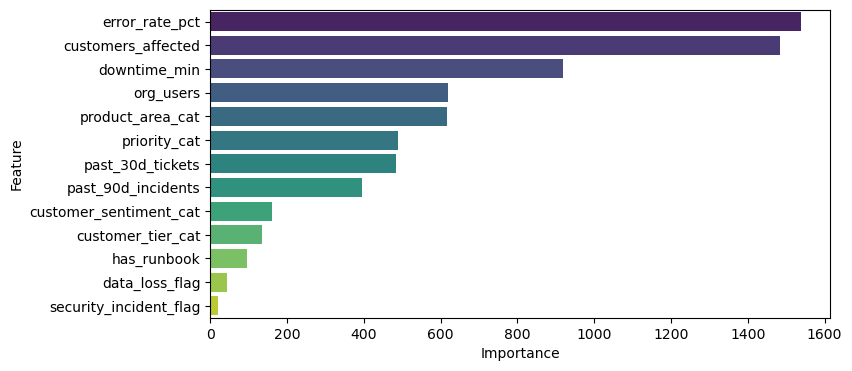

              precision    recall  f1-score   support

           0       1.00      0.95      0.97      9658
           1       0.22      0.88      0.35       161

    accuracy                           0.95      9819
   macro avg       0.61      0.91      0.66      9819
weighted avg       0.99      0.95      0.96      9819



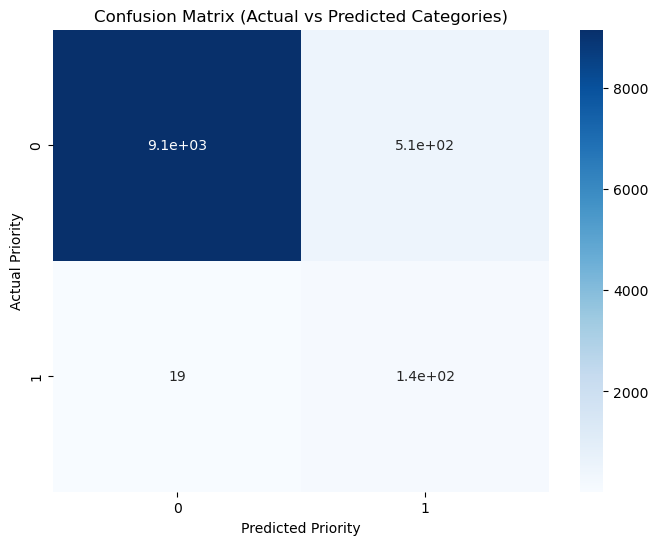

In [14]:
importances = best_lgbm.feature_importances_

feature_imp_df = pd.DataFrame({
    'Feature': important_col,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8, 4))
sns.barplot(data=feature_imp_df, x='Importance', y='Feature', palette='viridis')
plt.show()

from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(y_test, y_pred_lgbm))
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test,y_pred_lgbm),annot=True,cmap='Blues')
plt.title('Confusion Matrix (Actual vs Predicted Categories)')
plt.ylabel('Actual Priority')
plt.xlabel('Predicted Priority')
plt.show()

              precision    recall  f1-score   support

           0       1.00      0.91      0.95      9658
           1       0.14      0.92      0.25       161

    accuracy                           0.91      9819
   macro avg       0.57      0.91      0.60      9819
weighted avg       0.98      0.91      0.94      9819



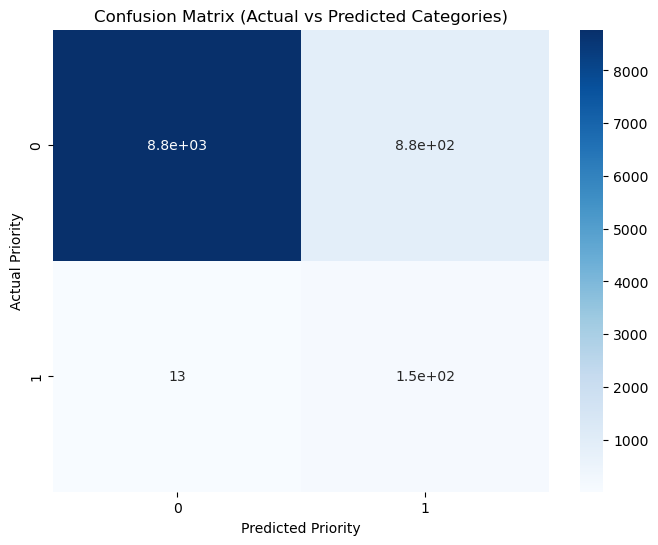

In [16]:
y_prob_lgbm = best_lgbm.predict_proba(X_test)[:, 1]
custom_threshold = 0.20
y_pred_custom = (y_prob_lgbm >= custom_threshold).astype(int)

print(classification_report(y_test, y_pred_custom))

plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test,y_pred_custom),annot=True,cmap='Blues')
plt.title('Confusion Matrix (Actual vs Predicted Categories)')
plt.ylabel('Actual Priority')
plt.xlabel('Predicted Priority')
plt.show()